In [34]:
library(tidyverse)
library(repr)
library(tidymodels)
library(cowplot)
library(ggplot2)

In [29]:
players <- read.csv("players.csv")
sessions <- read.csv("sessions.csv")

head(players)
head(sessions)
dim(players)
dim(sessions)

summary(players)
summary(sessions)

,experience,subscribe,hashedEmail,played_hours,name,gender,Age
,<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<int>
1,Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
2,Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
3,Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
4,Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
5,Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
6,Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


,hashedEmail,start_time,end_time,original_start_time,original_end_time
,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024 18:12,30/06/2024 18:24,1.71977e+12,1.71977e+12
2,36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024 23:33,17/06/2024 23:46,1.71867e+12,1.71867e+12
3,f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024 17:34,25/07/2024 17:57,1.72193e+12,1.72193e+12
4,bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,25/07/2024 03:22,25/07/2024 03:58,1.72188e+12,1.72188e+12
5,36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,25/05/2024 16:01,25/05/2024 16:12,1.71665e+12,1.71665e+12
6,bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,23/06/2024 15:08,23/06/2024 17:10,1.71916e+12,1.71916e+12


[1] 196   7

[1] 1535    5

  experience        subscribe       hashedEmail         played_hours    
 Length:196         Mode :logical   Length:196         Min.   :  0.000  
 Class :character   FALSE:52        Class :character   1st Qu.:  0.000  
 Mode  :character   TRUE :144       Mode  :character   Median :  0.100  
                                                       Mean   :  5.846  
                                                       3rd Qu.:  0.600  
                                                       Max.   :223.100  
                                                                        
     name              gender               Age       
 Length:196         Length:196         Min.   : 9.00  
 Class :character   Class :character   1st Qu.:17.00  
 Mode  :character   Mode  :character   Median :19.00  
                                       Mean   :21.14  
                                       3rd Qu.:22.75  
                                       Max.   :58.00  
                               

 hashedEmail         start_time          end_time         original_start_time
 Length:1535        Length:1535        Length:1535        Min.   :1.712e+12  
 Class :character   Class :character   Class :character   1st Qu.:1.716e+12  
 Mode  :character   Mode  :character   Mode  :character   Median :1.719e+12  
                                                          Mean   :1.719e+12  
                                                          3rd Qu.:1.722e+12  
                                                          Max.   :1.727e+12  
                                                                             
 original_end_time  
 Min.   :1.712e+12  
 1st Qu.:1.716e+12  
 Median :1.719e+12  
 Mean   :1.719e+12  
 3rd Qu.:1.722e+12  
 Max.   :1.727e+12  
 NA's   :2          

**Data Description:**

**players.csv**

| Variable         | Type        | Description                                     | 
|------------------|-------------|-------------------------------------------------|
| experience | Character | Self-reported experience (Beginner–Expert)     |
| subscribe        | Logical | Whether the player subscribed to the newsletter, TRUE = 73.47% |
| hashedEmail | Character | Unique player identifier |
| played_hours     | Numeric     | Total number of hours the player has played     | 
| name | Character | Player names |
| gender           | Character | Player gender (Male/Female/Other)               |
| Age              | Numeric     | Player age in years                             | 

- There are 7 variables in players.csv, with 196 observations



**sessions.csv**

| Variable       | Type        | Description                                      |
|----------------|-------------|--------------------------------------------------|
| email_hash     | Character | Unique player identifier             |
| start_time     | Character | Session start time <dd/mm/yyyy hh:mm>  |
| end_time       | Character | Session end time <dd/mm/yyyy hh:mm>   | 
| original_start_time   | Double     | Session start time in Unix timestamp (ms)  |
| original_end_time   | Double     | Session end time in Unix timestamp (ms) |

- There are 5 variables in sessions.csv with 1535 observations



**Overall Observations/Problems**

- Some categorical variables (e.g., `experience`, `gender`) may contain typos or inconsistent categories.
- `played_hours` includes people who's played 0 hours (didn't play), so there are extra rows that doesn't need to be there
- The timestamps in `sessions.csv` use Unix milliseconds, which tells you around the time they're online, though does not capture the exact moment they're on (for example, it'll show the same timestamp if they were on for a short period)
- The experience is self-reported, meaning there's no standard way of actually identifying their experience.
- These data were collected automatically through the research group’s MineCraft server logs, which tells you their session times, though may miss contextual factors such as network issues or AFK time.

**Questions:**

The broad question we will be looking at is question 1: "What player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and how do these features differ between various player types?". A specific question I've developed from this is "Can player demographic variables such as the self-identified skill level, age and gender help predict the newsletter subscription status?"

The dataset includes variables describing player demographics, such as age, self-reported experience, and reported gender. As well, we can use the column of whether they've subscribed to help predict. To address the question, the data will first be cleaned and wrangled to remove those that are NA, or not useful to the predictions (such as "prefer not to say" for gender).

The data will then be split into training (75%) and testing (25%) sets. A K-NN classification model will be trained on the player experience variables to predict newsletter subscription. K-NN is suitable because it can model non-linear patterns and categorical outcomes by comparing each player to their most similar peers, allowing us to evaluate how strongly experience predicts engagement. The linear regression model is better for predicting continuous numeric variables, but we're trying to predict a categorical one. Thus why the K-NN model was chosen.

Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


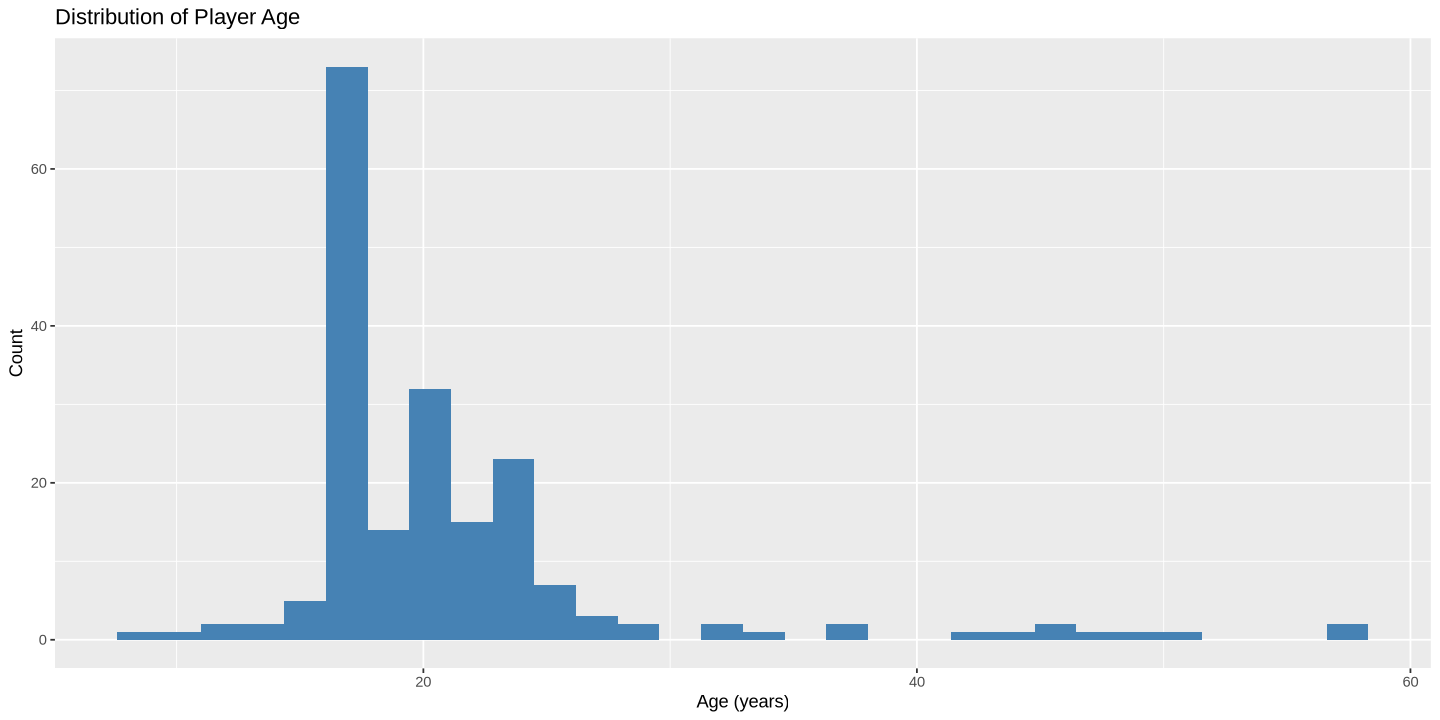

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


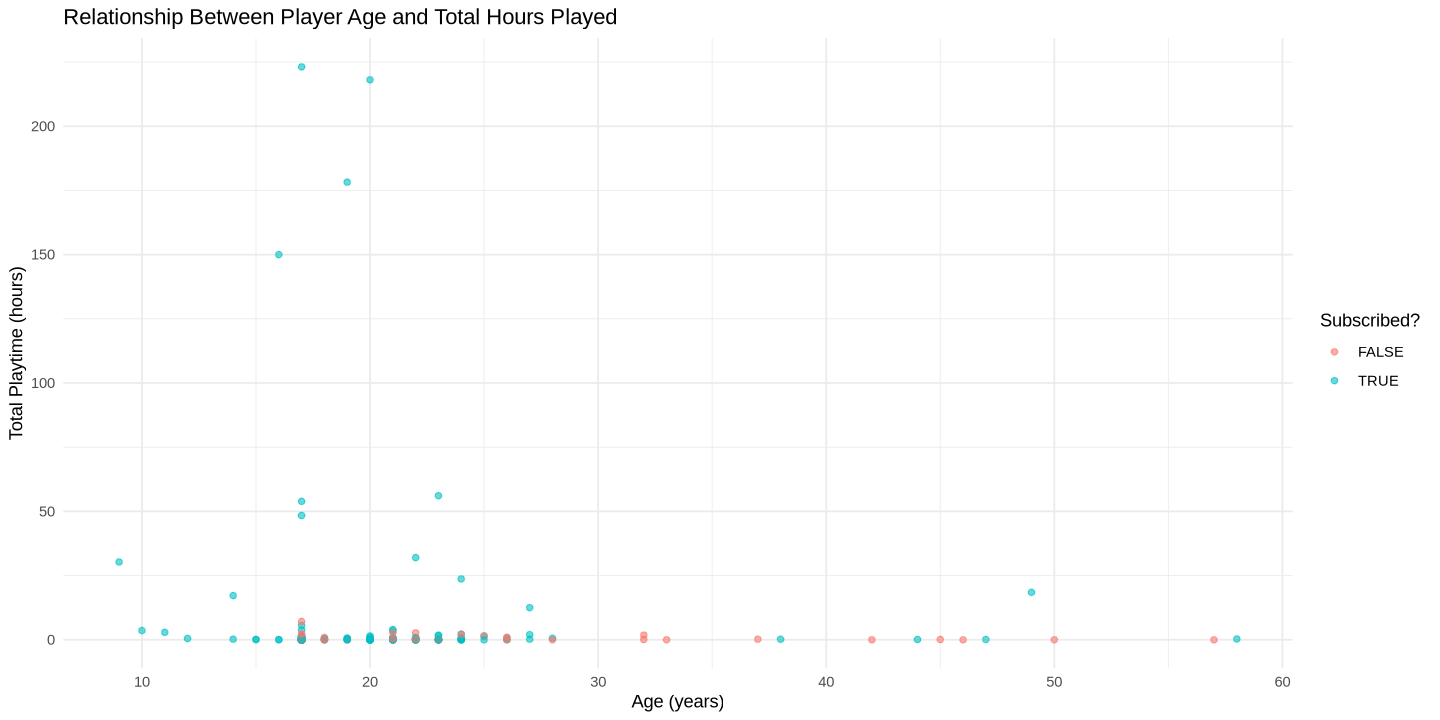

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


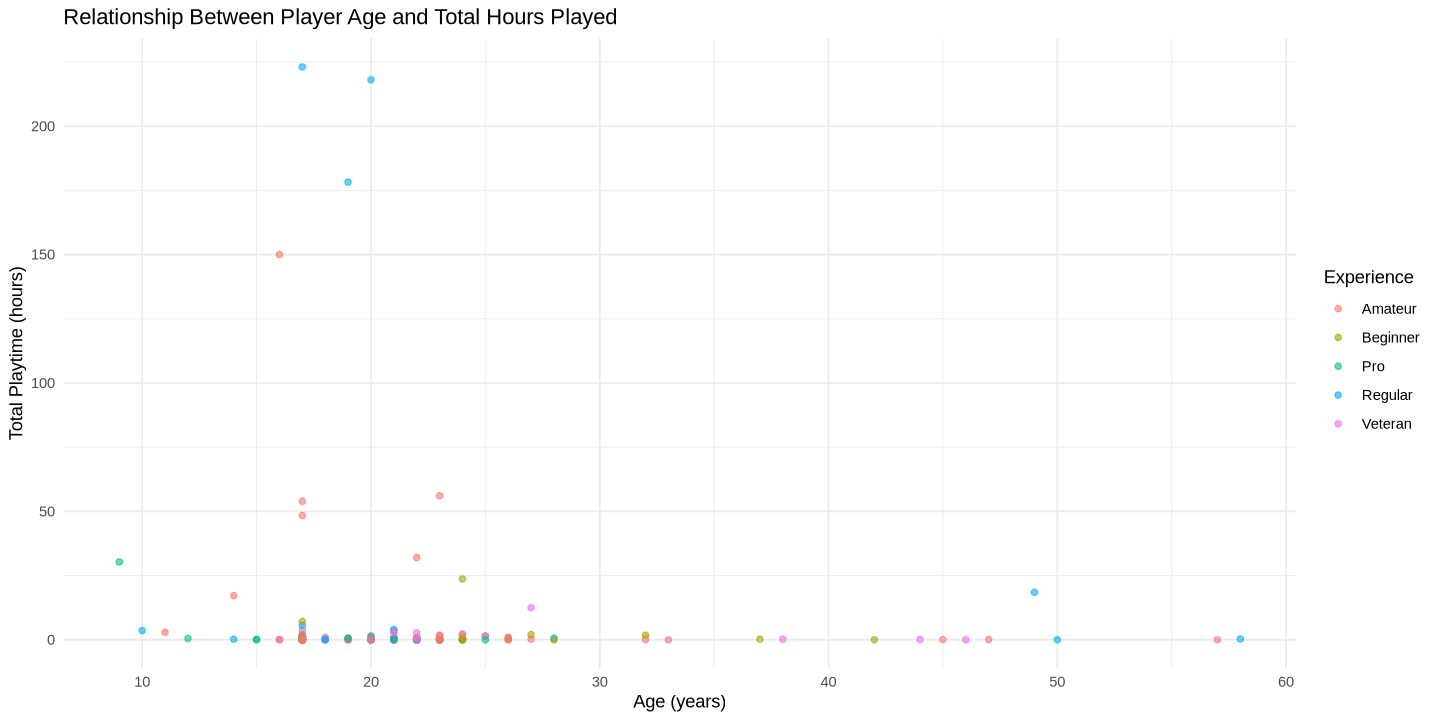

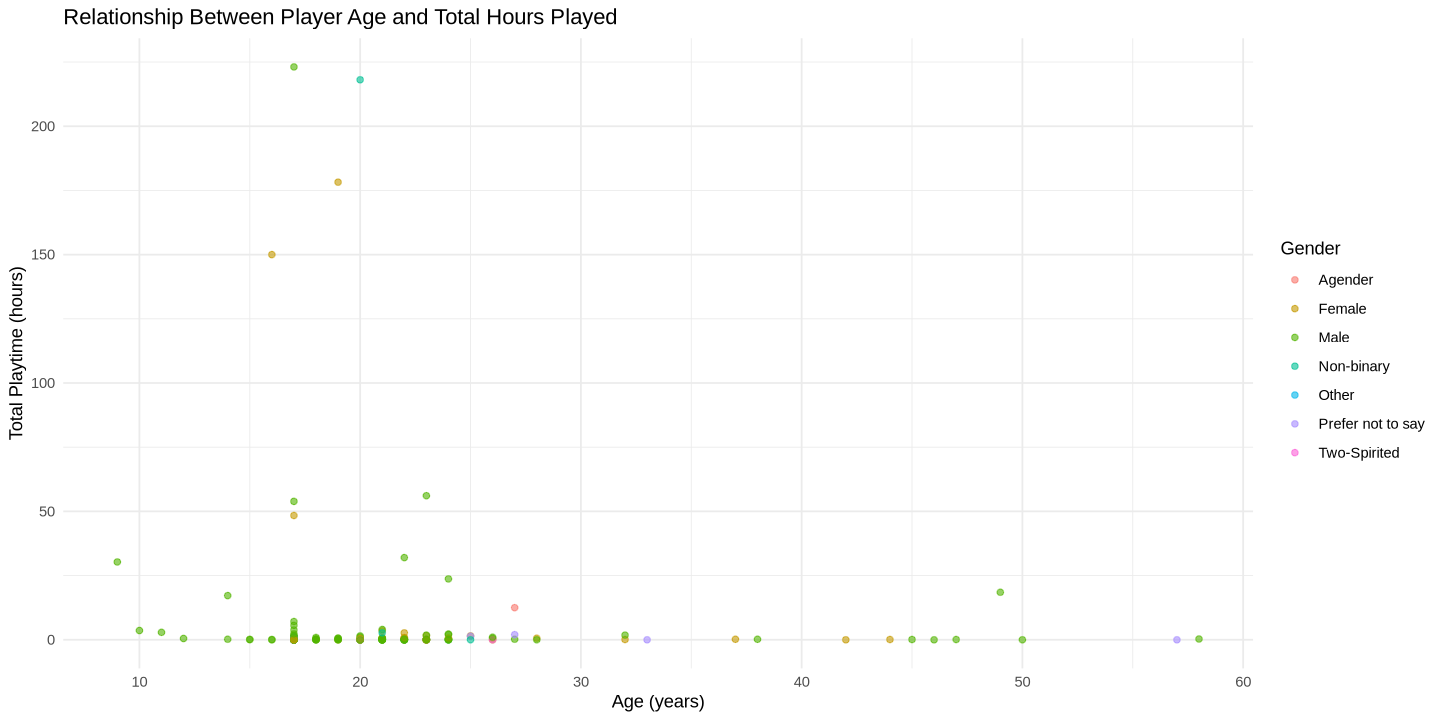

In [39]:
options(repr.plot.width = 12, repr.plot.height = 6)

Age_dist <- ggplot(players, aes(x = Age)) +
              geom_histogram(bins = 30, fill = "steelblue") +
              labs(
                    title = "Distribution of Player Age",
                    x = "Age (years)",
                    y = "Count")

Subscribed <- ggplot(players, aes(x = Age, y = played_hours, color = subscribe)) +
                  geom_point(alpha = 0.6) +
                  labs(
                        title = "Relationship Between Player Age and Total Hours Played",
                        x = "Age (years)",
                        y = "Total Playtime (hours)",
                        color = "Subscribed?") +
                  theme_minimal()

Experience <- ggplot(players, aes(x = Age, y = played_hours, color = experience)) +
                  geom_point(alpha = 0.6) +
                  labs(
                        title = "Relationship Between Player Age and Total Hours Played",
                        x = "Age (years)",
                        y = "Total Playtime (hours)",
                        color = "Experience") +
                  theme_minimal()

Gender <- ggplot(players, aes(x = Age, y = played_hours, color = gender)) +
                  geom_point(alpha = 0.6) +
                  labs(
                        title = "Relationship Between Player Age and Total Hours Played",
                        x = "Age (years)",
                        y = "Total Playtime (hours)",
                        color = "Gender") +
                  theme_minimal()

Age_dist
Subscribed
Experience
Gender

**Exploratory Data Analysis and Visualization**

| Variable | Mean |
|---------|------|
| age | 21.14 |
| played_hours | 5.85 |
| original_start_time | 1.719e+12  |
|original_end_time  | 1.719e+12 |


- We see that the points on the scatterplot cluster towards younger ages, and the age distribution graph is right-skewed, which tells us that most of the players are younger
- There is almost no relationship that we can see between age and total playtime
- Those who are younger are more likely to subscribe to the newsletter as we see a higher proportion of TRUE, while among the older population, there's a higher proportion of FALSE
- There are a few outliers in hours played that may affect our k-nn model going into the project (and the outliers don't provide much information, as their gender and experience don't all match.
- The visualization helps determine whether hours played is likely to be predictive, whether age modifies that relationship, and whether subscription appears random or patterned.
- There are lots of players with 0 hours played, though I feel like their data could be needed in the long run during the project so I decided to leave them in for now.

**Methods and Planning**

To answer my question, “Can experience, total hours played and other characteristics predict newsletter subscription status?”, I will use a k-nearest neighbours (k-NN) classification model. This method is appropriate because my response variable, subscribe, is categorical, and k-NN directly predicts class labels based on similarity between observations. It also makes minimal assumptions about the underlying data distribution, which is useful given that playtime and session behaviour are looking non-linear.

The main assumptions of k-NN are that distance meaningfully represents similarity and that features are scaled so no variable dominates the distance calculation. A potential limitation is that k-NN can perform poorly with imbalanced classes and may be sensitive to noise or outliers. It can also be computationally slower for larger datasets.

For model comparison, I will use cross-validation to choose an optimal value of k, comparing accuracy across several k values. To prepare the data, I will remove missing values, and scale numeric features before going into it. I will then split the dataset into training (75%) and testing (25%) before applying cross-validation on the training set and evaluating final performance on the test set.

**Github Repository Link**: https://github.com/Maxisthatyou/DS101-Project